# AI-Based Career Recommendation System – EDA and Machine Learning Notebook

#### This notebook uses the synthetic dataset [AI-based Career Recommendation System](https://www.kaggle.com/datasets/adilshamim8/ai-based-career-recommendation-system/data) to:
- 1. Load and explore the dataset.
- 2. Perform extensive exploratory data analysis (EDA) to understand the data distribution.
- 3. Preprocess the data to prepare it for machine learning.
- 4. Build and evaluate a simple classification model to predict the recommended career.
- **Note:** The dataset is synthetic. The model and EDA steps serve as an example pipeline.

## Step 1: Import Libraries and Load Data

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# For preprocessing and modeling
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Set style for seaborn
sns.set(style="whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv("cs_career_dataset1.csv")
df.head()

,CandidateID,Name,Age,Education,Skills,Interests,Recommended_Career,Recommendation_Score
0,CS1001,Anaya Kumar,26,B.Tech IT,JavaScript;CSS;Networking;Communication,Technology,Web Developer,0.8901
1,CS1002,Karan Das,26,B.Tech CSE,Database Management;Linux;Python;Networking;Co...,Technology;Cloud Computing,Cloud Engineer,0.8869
2,CS1003,Pooja Gupta,22,BCA,Testing;Project Management;Leadership,Automation,DevOps Engineer,0.8065
3,CS1004,Aditi Kumar,23,BCA,Statistics;Algorithms,Artificial Intelligence,AI Engineer,0.7901
4,CS1005,Karan Roy,29,MCA,Python;Machine Learning;Problem Solving;Research,Data Analytics;Research,Data Scientist,0.8970


# Step 2: Data Overview
> Let's take a look at the basic structure, columns, and summary statistics of the dataset.

In [3]:
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()

Dataset Shape: (1500, 8)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CandidateID           1500 non-null   object 
 1   Name                  1500 non-null   object 
 2   Age                   1500 non-null   int64  
 3   Education             1500 non-null   object 
 4   Skills                1401 non-null   object 
 5   Interests             1500 non-null   object 
 6   Recommended_Career    1500 non-null   object 
 7   Recommendation_Score  1500 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 93.9+ KB


In [4]:
# Display summary statistics for numeric columns
df.describe()

,Age,Recommendation_Score
count,1500.000000,1500.000000
mean,24.568667,0.823873
std,2.869630,0.084511
min,20.000000,0.675100
25%,22.000000,0.749075
50%,25.000000,0.824000
75%,27.000000,0.894925
max,29.000000,0.974700


# Step 3: Exploratory Data Analysis (EDA)
## 3.1 Distribution of Age
> We'll look at the distribution of the `Age` column.

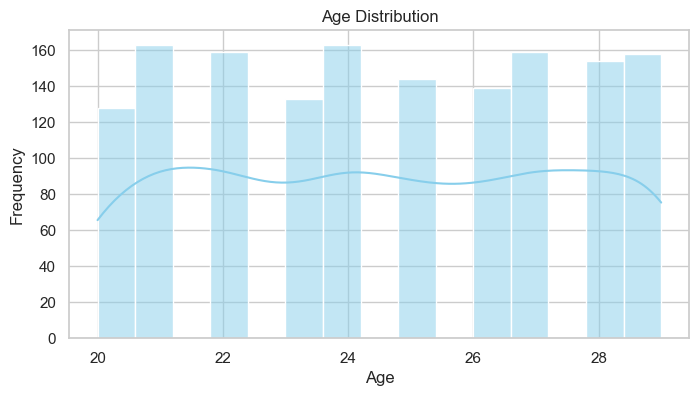

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=15, kde=True, color="skyblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## 3.2 Count of Education Levels
> Let's examine how many candidates fall into each education category.

<Axes: xlabel='count', ylabel='Education'>

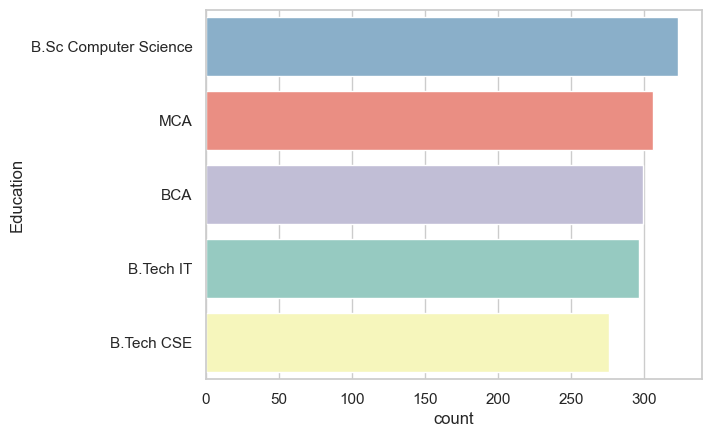

In [6]:
sns.countplot(
    y="Education",
    data=df,
    order=df["Education"].value_counts().index,
    hue="Education",
    palette="Set3",
    legend=False
)

## 3.3 Recommended Career Distribution
> A count plot for the `Recommended_Career` column to see the frequency of each career recommendation.

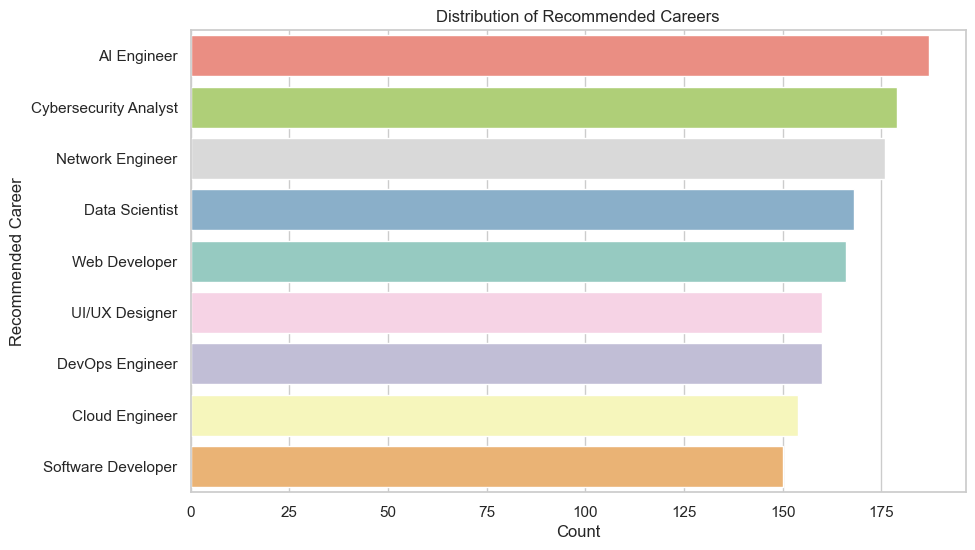

In [7]:
plt.figure(figsize=(10, 6))

sns.countplot(
    y="Recommended_Career",
    data=df,
    order=df["Recommended_Career"].value_counts().index,
    hue="Recommended_Career",   
    palette="Set3",
    legend=False                
)

plt.title("Distribution of Recommended Careers")
plt.xlabel("Count")
plt.ylabel("Recommended Career")
plt.show()

## 3.4 Recommendation Score Distribution
> Visualize the distribution of the `Recommendation_Score`.

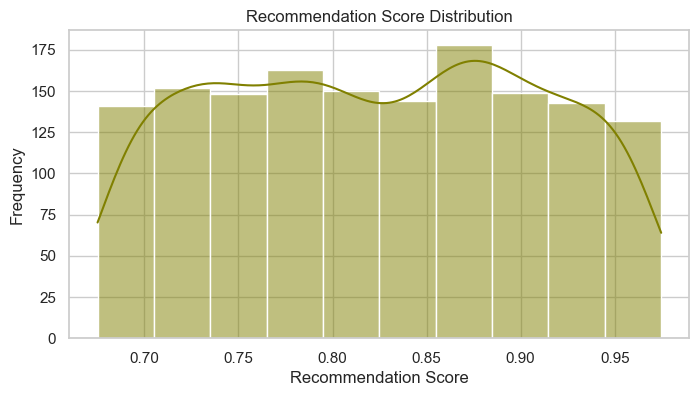

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Recommendation_Score'], bins=10, kde=True, color="olive")
plt.title("Recommendation Score Distribution")
plt.xlabel("Recommendation Score")
plt.ylabel("Frequency")
plt.show()

## 3.5 Skills and Interests Exploration 
> Since `Skills` and `Interests` are stored as semicolon-separated strings, we can explore the most common items. <br>
> We'll split the strings and count the frequency of each skill and interest.

In [9]:
# Function to split semicolon-separated values and count occurrences
def count_items(series):
    items = series.dropna().apply(lambda x: x.split(";"))
    flat_list = [item.strip() for sublist in items for item in sublist]
    return pd.Series(flat_list).value_counts()

In [10]:
# Count Skills
skills_count = count_items(df["Skills"])
print("Most common skills:\n", skills_count)

Most common skills:
 Python                  461
Cybersecurity           277
Testing                 266
Database Management     260
Networking              260
Linux                   237
Statistics              235
Machine Learning        216
Communication           215
Problem Solving         213
Leadership              202
Programming             194
Teamwork                188
Research                185
Critical Thinking       183
Algorithms              154
Risk Management         138
Design                  135
Presentation            129
Creativity              124
Project Management      119
Graphic Design          119
React                   107
Debugging                98
HTML                     95
SQL                      93
CSS                      93
JavaScript               92
Java                     92
C++                      89
Power BI                 89
Data Analysis            82
Software Development     75
Name: count, dtype: int64


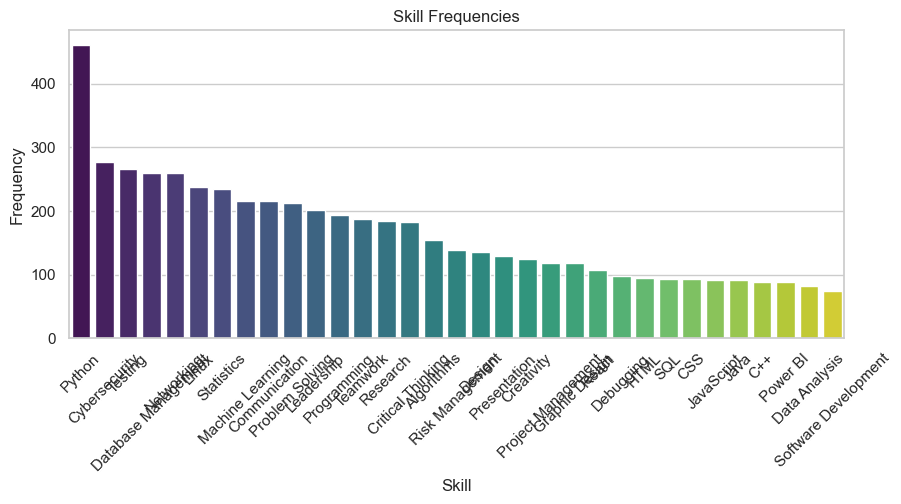

In [11]:
# Plot skills count
plt.figure(figsize=(10, 4))

sns.barplot(
    x=skills_count.index,
    y=skills_count.values,
    hue=skills_count.index,   
    palette="viridis",
    legend=False              
)

plt.xticks(rotation=45)
plt.title("Skill Frequencies")
plt.xlabel("Skill")
plt.ylabel("Frequency")
plt.show()

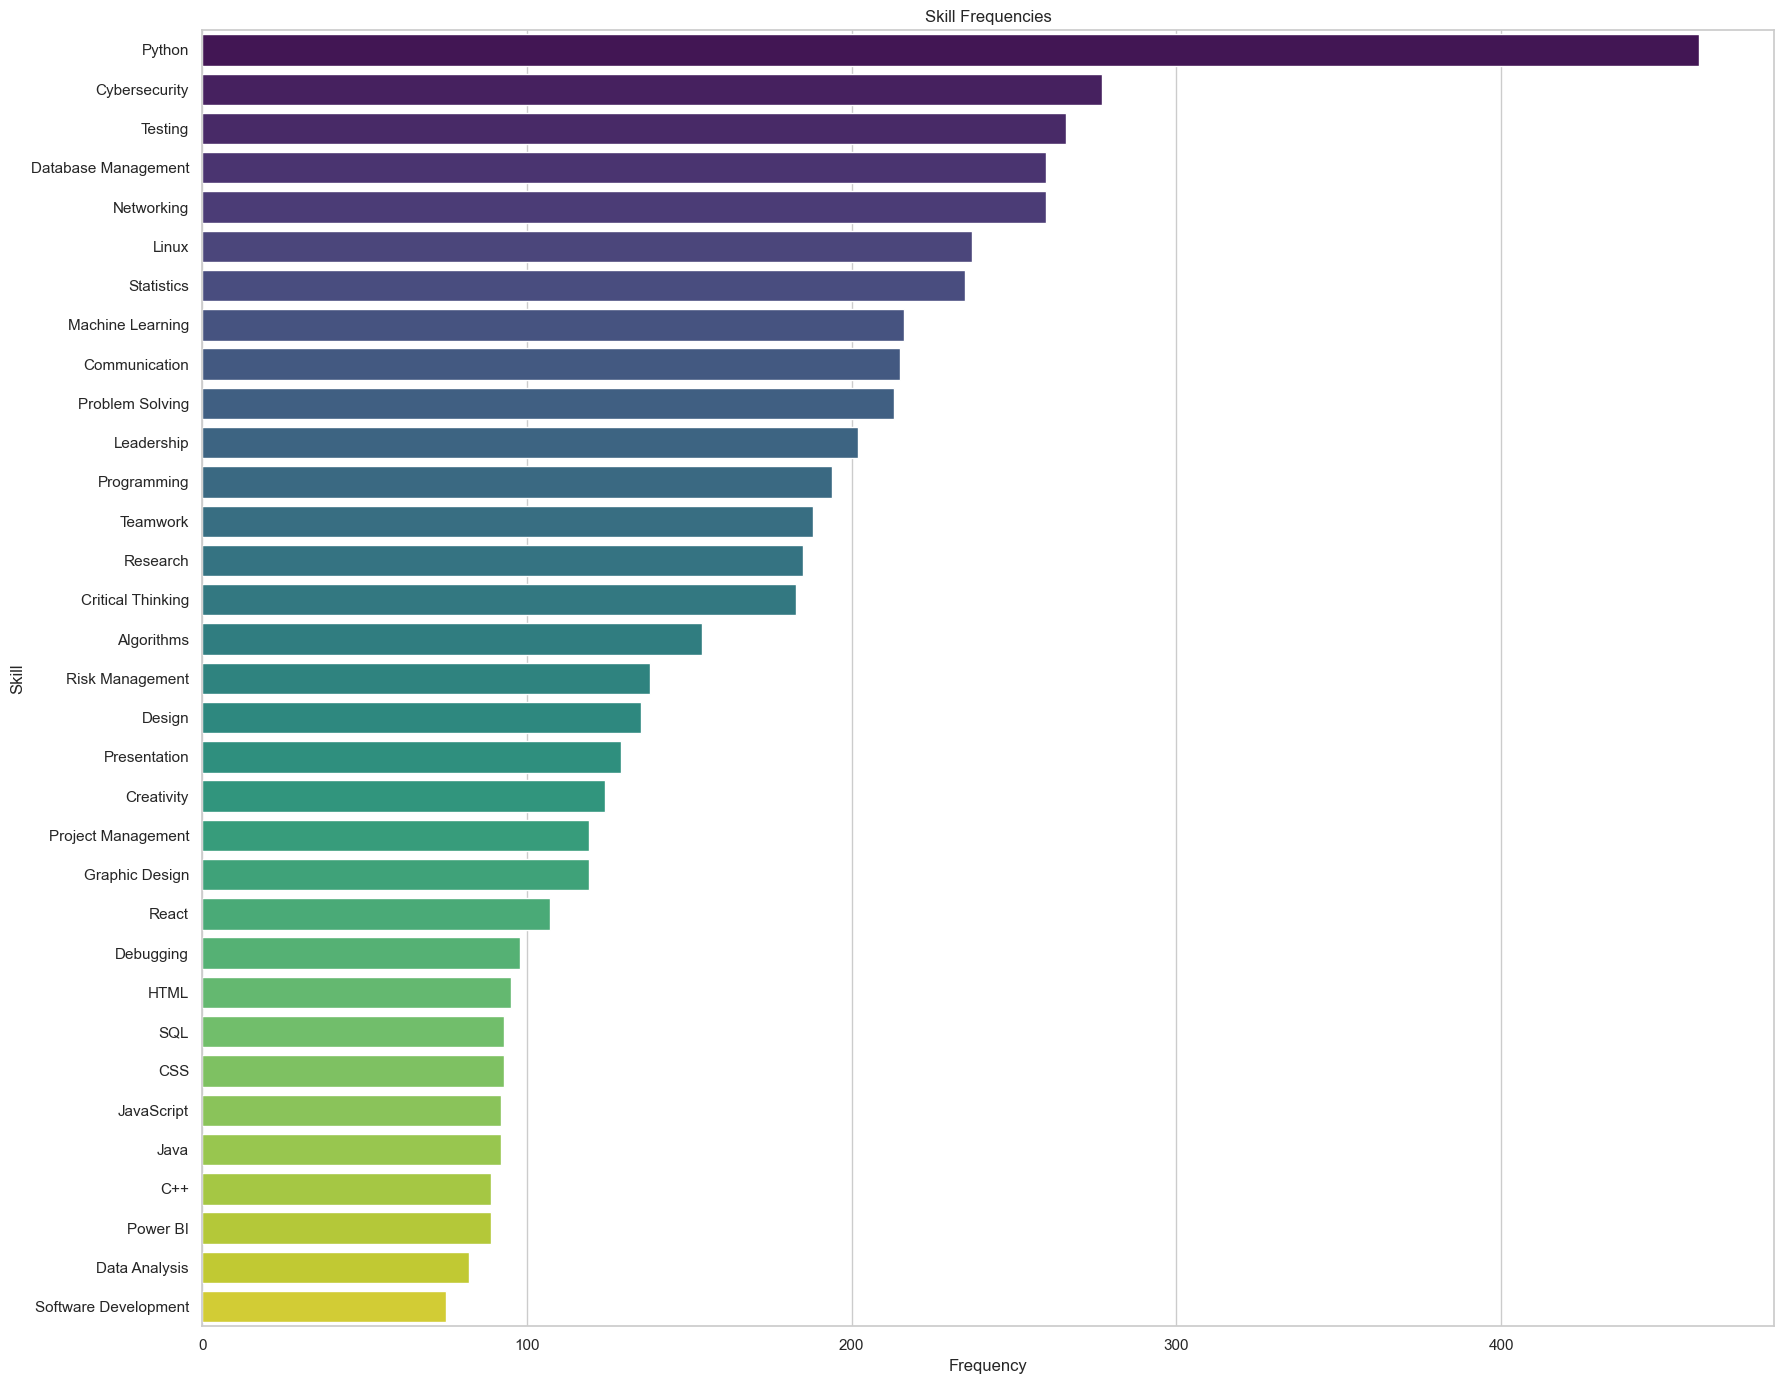

In [12]:
# Plot as horizontal bars with more vertical space
plt.figure(figsize=(18, 14))

sns.barplot(
    x=skills_count.values,
    y=skills_count.index,
    hue=skills_count.index,   
    palette="viridis",
    legend=False              
)

plt.title("Skill Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [13]:
# Count Interests
interests_count = count_items(df["Interests"])
print("Most common interests:\n", interests_count)

Most common interests:
 Technology                 705
Research                   345
Creativity                 239
Artificial Intelligence    148
Security                   133
Networking                 131
Design                     129
Automation                 121
Cloud Computing            119
Programming                108
Data Analytics              90
Name: count, dtype: int64


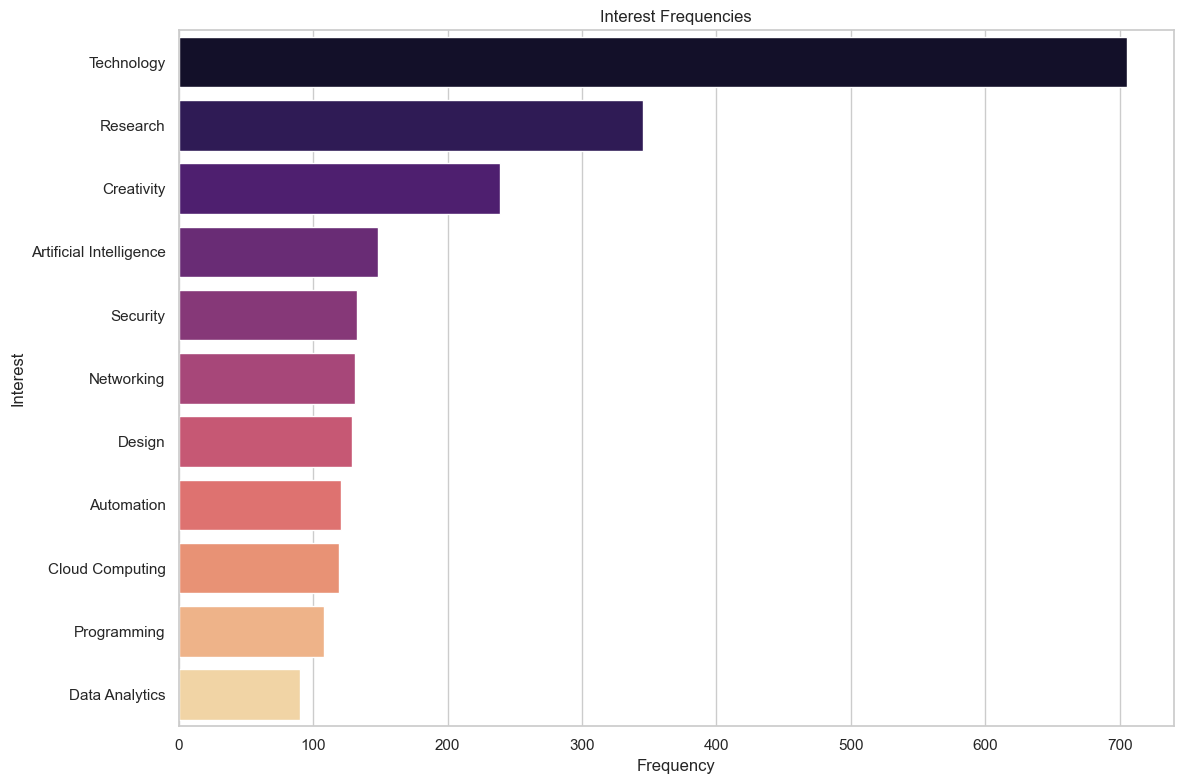

In [14]:
# Plot interests count as horizontal bars
plt.figure(figsize=(12, 8))

sns.barplot(
    x=interests_count.values,
    y=interests_count.index,
    hue=interests_count.index,   
    palette="magma",
    legend=False                 
)

plt.title("Interest Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Interest")
plt.tight_layout()
plt.show()

1. LOAD DATA

In [15]:
# Select features and target variable
df["Skills"] = df["Skills"].fillna("")
df["Interests"] = df["Interests"].fillna("")

df["Combined_Text"] = df["Skills"].astype(str) + " ; " + df["Interests"].astype(str)
df.head()

,CandidateID,Name,Age,Education,Skills,Interests,Recommended_Career,Recommendation_Score,Combined_Text
0,CS1001,Anaya Kumar,26,B.Tech IT,JavaScript;CSS;Networking;Communication,Technology,Web Developer,0.8901,JavaScript;CSS;Networking;Communication ; Tech...
1,CS1002,Karan Das,26,B.Tech CSE,Database Management;Linux;Python;Networking;Co...,Technology;Cloud Computing,Cloud Engineer,0.8869,Database Management;Linux;Python;Networking;Co...
2,CS1003,Pooja Gupta,22,BCA,Testing;Project Management;Leadership,Automation,DevOps Engineer,0.8065,Testing;Project Management;Leadership ; Automa...
3,CS1004,Aditi Kumar,23,BCA,Statistics;Algorithms,Artificial Intelligence,AI Engineer,0.7901,Statistics;Algorithms ; Artificial Intelligence
4,CS1005,Karan Roy,29,MCA,Python;Machine Learning;Problem Solving;Research,Data Analytics;Research,Data Scientist,0.8970,Python;Machine Learning;Problem Solving;Resear...


2. TRAIN / TEST SPLIT

In [16]:
X = df[["Age", "Education", "Combined_Text"]]
y = df["Recommended_Career"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 1200, Test size: 300


3. PREPROCESSING PIPELINE

In [18]:
text_features = ["Combined_Text"]
numeric_features = ["Age"]
cat_features = ["Education"]

preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(
            max_features=1500,
            token_pattern=r"[^;]+",     # treat each skill/interest as a token
            lowercase=True
        ), "Combined_Text"),
        ("ohe", OneHotEncoder(handle_unknown="ignore"), ["Education"]),
        ("scaler", StandardScaler(), ["Age"])
    ],
    sparse_threshold=0.3
    )

Model

In [30]:
models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        random_state=42,
        n_jobs=-1,
        max_depth=18,
    min_samples_split=4
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=500
    ),

    "SVM": SVC(kernel="linear", probability=True),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

Train Model

In [39]:
results = []

for name, model in models.items():

    # Create pipeline for current model
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("classifier", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append([
        name,
        round(acc, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4)
    ])

Evaluate

In [40]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print("\nModel Comparison:\n")
print(results_df.sort_values(by="Accuracy", ascending=False))


Model Comparison:

                 Model  Accuracy  Precision  Recall  F1 Score
1  Logistic Regression    0.8600     0.8643  0.8600    0.8604
2                  SVM    0.8600     0.8628  0.8600    0.8600
0        Random Forest    0.8567     0.8632  0.8567    0.8577
3        Decision Tree    0.7400     0.7438  0.7400    0.7399


Pipeline

In [41]:
final_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", final_model)
])

pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tfidf', ...), ('ohe', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Save Pipeline

In [43]:
joblib.dump(pipeline, "career_recommender_model.joblib")

print("\nModel saved as career_recommender_model.joblib")


Model saved as career_recommender_model.joblib


DEFINE PREDICTION FUNCTION

In [172]:
import joblib
import numpy as np
import pandas as pd

pipeline = joblib.load("career_recommender_model.joblib")

def predict_top_3_careers(age, education, skills_list, interests_list):
    combined_text = ";".join(skills_list) + ";" + ";".join(interests_list)

    # Convert into DataFrame
    user_df = pd.DataFrame([{
        "Age": age,
        "Education": education,
        "Combined_Text": combined_text
    }])

    # Predict proba
    proba = pipeline.predict_proba(user_df)[0]
    classes = pipeline.classes_

    # Top 3 indices
    top3_idx = np.argsort(proba)[-3:][::-1]

    # Return tuples [(career, probability), ...]
    return [(classes[i], float(proba[i])) for i in top3_idx]


In [173]:
results = predict_top_3_careers(
    age=25,
    education="Bachelor's",
    skills_list=["Python", "Data Analysis", "Machine Learning", "Critical Thinking"],
    interests_list=["Technology", "Data Science", "Innovation"]
)

print("\nExample user prediction (Top 3):")
for career, prob in results:
    print(f"- {career} ({prob:.2f})")



Example user prediction (Top 3):
- Data Scientist (0.61)
- AI Engineer (0.19)
- Cloud Engineer (0.07)


In [174]:
import sklearn
print(sklearn.__version__)

1.6.1
